In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


In [3]:
users_info.shape

(1000, 4)

In [4]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [5]:
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
users_info = users_info[~users_info['age'].isnull() & ~users_info['gender'].isnull()]
users_info.shape

(865, 4)

In [7]:
Q1 = np.percentile(users_info['age'], 25)
Q3 = np.percentile(users_info['age'], 75)
IQR = Q3 - Q1
users_info_clean = users_info[(users_info['age'] > Q1 - 1.5*IQR) & (users_info['age'] < Q3 + 1.5*IQR)]

<AxesSubplot:xlabel='age', ylabel='Count'>

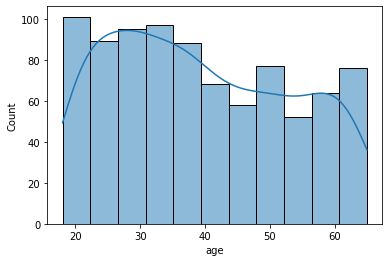

In [8]:
sns.histplot(users_info_clean['age'], kde = True)

In [9]:
group_table = users_info_clean.groupby(['gender', 'city']).agg(people_count = ('id_user', 'count')).reset_index()
group_table

,gender,city,people_count
0,female,Екатеринбург,55
1,female,Казань,53
2,female,Москва,220
3,female,СПб,123
4,male,Екатеринбург,78
5,male,Казань,77
6,male,Москва,105
7,male,СПб,154


In [10]:
group_table = group_table.pivot_table(
    index = 'city',
    columns = 'gender',
    values = 'people_count',
    aggfunc = 'sum',
    fill_value = 0
)
group_table

gender,female,male
city,,
Екатеринбург,55,78
Казань,53,77
Москва,220,105
СПб,123,154


In [11]:
group_table.columns = ['female', 'male']
group_table = group_table.reset_index()
group_table

,city,female,male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


In [12]:
group_table['female_share'] = round(group_table['female'] / (group_table['female'] + group_table['male']) * 100, 2)
group_table

,city,female,male,female_share
0,Екатеринбург,55,78,41.35
1,Казань,53,77,40.77
2,Москва,220,105,67.69
3,СПб,123,154,44.40


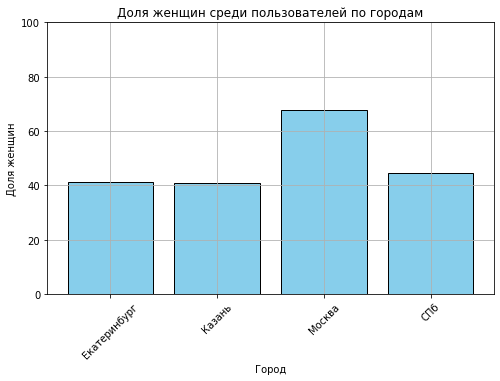

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(group_table['city'], group_table['female_share'], color='skyblue', edgecolor='black')
plt.xlabel('Город')
plt.ylabel('Доля женщин')
plt.title('Доля женщин среди пользователей по городам')
plt.ylim(0, 100)  
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [14]:
pay_mon = pd.read_csv('payments_monthly.csv')

In [15]:
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [16]:
user_avg = pay_mon.groupby('id_user').agg({'cnt_total':'mean'}).reset_index()
user_avg

,id_user,cnt_total
0,1000,3.666667
1,1001,11.727273
2,1002,11.636364
3,1003,5.166667
4,1004,2.000000
...,...,...
964,1994,7.000000
965,1995,11.500000
966,1996,1.500000
967,1997,5.000000


In [17]:
low_limit = np.percentile(user_avg['cnt_total'], 33)
high_limit = np.percentile(user_avg['cnt_total'], 67)

In [18]:
labels = ['Мало', 'Средне', 'Много']
user_avg['activity_group'] = pd.cut(
    user_avg['cnt_total'],
    bins=[0, low_limit, high_limit, 100],
    labels=labels,
    right=False
)
user_avg

,id_user,cnt_total,activity_group
0,1000,3.666667,Мало
1,1001,11.727273,Много
2,1002,11.636364,Много
3,1003,5.166667,Средне
4,1004,2.000000,Мало
...,...,...,...
964,1994,7.000000,Средне
965,1995,11.500000,Много
966,1996,1.500000,Мало
967,1997,5.000000,Средне


In [19]:
user_avg.groupby(['activity_group']).agg(group_count = ('activity_group', 'count')).reset_index()

,activity_group,group_count
0,Мало,292
1,Средне,356
2,Много,321
